<a href="https://colab.research.google.com/github/merasifa/PCVK/blob/main/WEEK7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Pengolahan Citra Digital - Week 7

**Nama:** Tiara Mera Sifa <br>
**NIM:** 2141720247 <br>
**Kelas:** TI-3B <br>


In [1]:
from google.colab import drive
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

In [3]:
# Konvulasi Citra
def convolution2d(image, kernel, stride=1, padding=0):
    # Get image and kernel dimensions
    image_h, image_w = image.shape
    kernel_h, kernel_w = kernel.shape

    # Flip the kernel (for convolution)
    kernel = np.flipud(np.fliplr(kernel))

    # Add padding to the image
    if padding > 0:
        image_padded = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')
    else:
        image_padded = image

    # Calculate the dimensions of the output
    output_h = (image_h + 2 * padding - kernel_h) // stride + 1
    output_w = (image_w + 2 * padding - kernel_w) // stride + 1

    # Initialize the output matrix
    output = np.zeros((output_h, output_w))

    # Perform the convolution operation
    for y in range(0, output_h):
        for x in range(0, output_w):
            # Extract the region of interest from the image
            y_start, x_start = y * stride, x * stride
            y_end, x_end = y_start + kernel_h, x_start + kernel_w
            region = image_padded[y_start:y_end, x_start:x_end]

            # Perform element-wise multiplication and sum
            output[y, x] = np.sum(region * kernel)

    return output

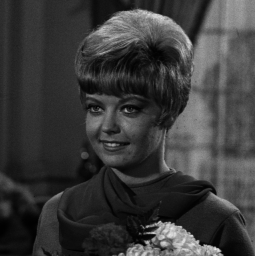

In [4]:
img = cv.imread('/content/gdrive/MyDrive/PCVK/Images/perempuan.png')
img = cv.cvtColor(img, cv.COLOR_BGR2GRAY)
cv2_imshow(img)

### **SHARPEN**

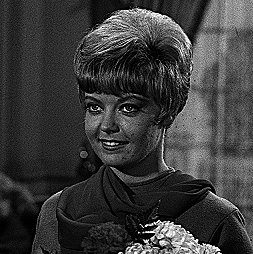

In [5]:
kernel_sharpen = np.array([[0,-1,0],
                           [-1,5,-1],
                           [0,-1,0]])
img_sharpen = convolution2d(img, kernel_sharpen, stride=1, padding=0)
cv2_imshow(img_sharpen)

### **EMBOSS**

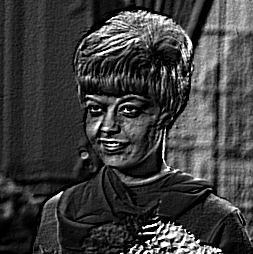

In [12]:
kernel_emboss = np.array([[-2,-1,0],
                           [-1,1,1],
                           [0,1,2]])
img_emboss = convolution2d(img, kernel_emboss, stride=1, padding=0)
cv2_imshow(img_emboss)

### **Left Sobel Edge Detection**

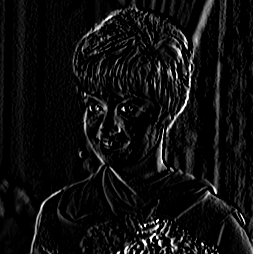

In [13]:
kernel_ls = np.array([[1,0,-1],
                      [2,0,-2],
                      [1,0,-1]])
img_ls = convolution2d(img, kernel_ls, stride=1, padding=0)
cv2_imshow(img_ls)

### **Canny Edge Detection**

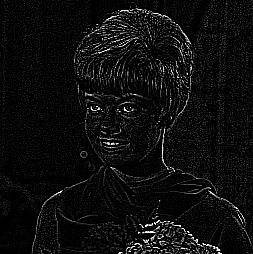

In [14]:
kernel_canny = np.array([[-1,-1,-1],
                         [-1,8,-1],
                         [-1,-1,-1]])
img_canny = convolution2d(img, kernel_canny, stride=1, padding=0)
cv2_imshow(img_canny)

### **Prewitt Edge Detection**

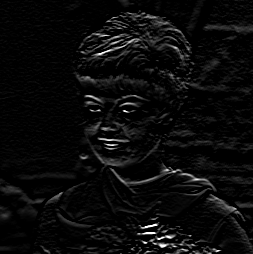

In [15]:
kernel_prewitt = np.array([[-1,-1,-1],
                           [0, 0, 0],
                           [1, 1, 1]])
img_prewitt = convolution2d(img, kernel_prewitt, stride=1, padding=0)
cv2_imshow(img_prewitt)

### **5x5 Gaussian Blur**

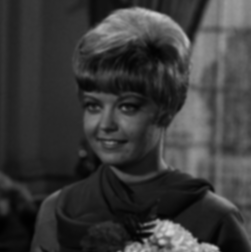

In [16]:
kernel_gaussian = (1/256) * np.array([[1,  4,  6,  4, 1],
                                      [4, 16, 24, 16, 4],
                                      [6, 24, 36, 24, 6],
                                      [4, 16, 24, 16, 4],
                                      [1,  4,  6,  4, 1]])
img_gaussian = convolution2d(img, kernel_gaussian, stride=1, padding=0)
cv2_imshow(img_gaussian)

### **21x21 Gaussian Blur**

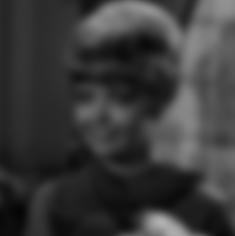

In [17]:
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size,sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.T

output_gauss = convolution2d(img, gauss_kernel, stride=1, padding=0)
cv2_imshow(output_gauss)